<a href="https://colab.research.google.com/github/lakhbir-05/CodeAlpha_Credit-scoring-model/blob/main/credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightgbm xgboost catboost

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d laotse/credit-risk-dataset
!unzip credit-risk-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
License(s): CC0-1.0
100% 368k/368k [00:00<00:00, 45.5MB/s]

Archive:  credit-risk-dataset.zip
  inflating: credit_risk_dataset.csv  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


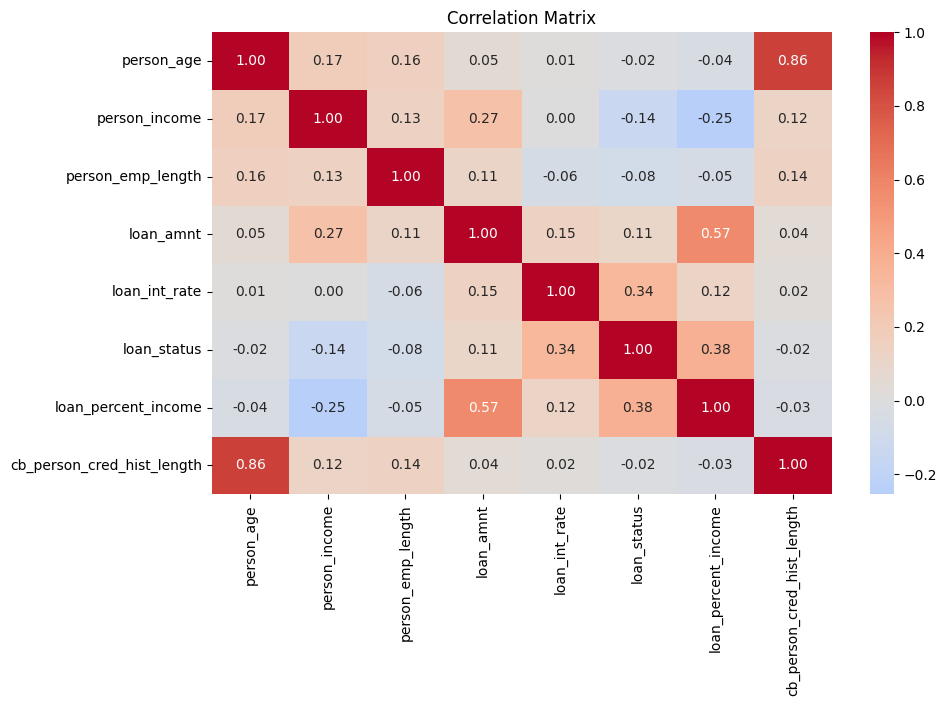

In [ ]:
df = pd.read_csv('/content/credit_risk_dataset.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df) * 100).round(2),
    "Unique Values": df.nunique(),
    "Unique Category": [df[col].unique() for col in df.columns],
})

info_df

corr_matrix = df.corr(numeric_only=True)
corr_matrix

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# target distribution

Loan Distribution:

  Non-default:  25473 (78.18%)
  Default:      7108  (21.82%)


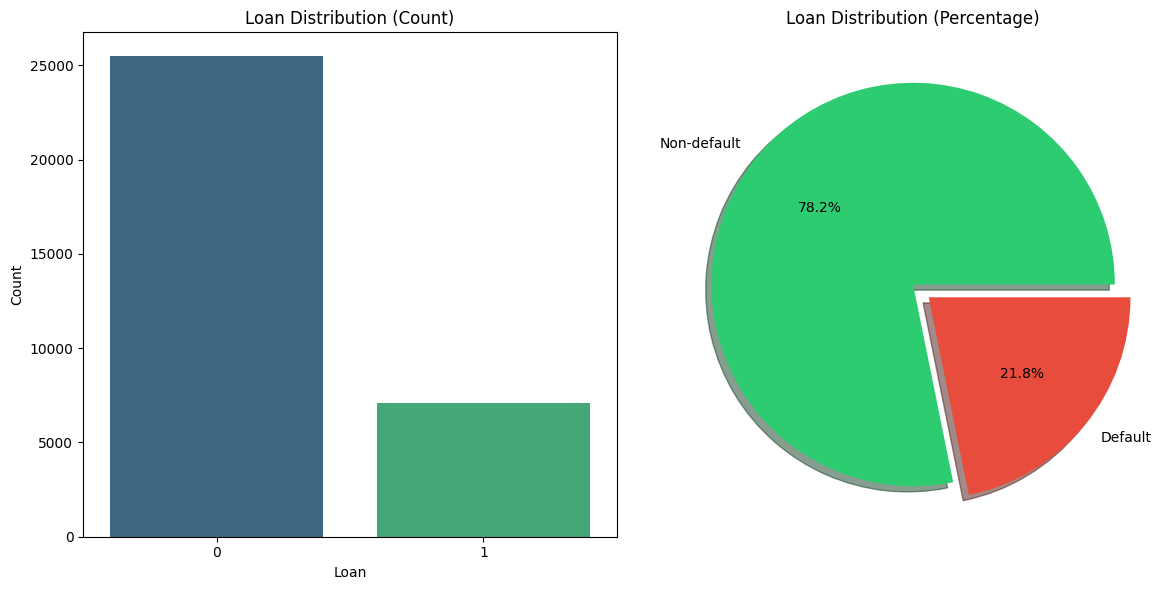

In [ ]:
loan_dist = df['loan_status'].value_counts()
loan_pct = df['loan_status'].value_counts(normalize=True) * 100

print("Loan Distribution:\n")
print(f"  Non-default:  {loan_dist[0]} ({loan_pct[0]:.2f}%)")  # 0
print(f"  Default:      {loan_dist[1]}  ({loan_pct[1]:.2f}%)") # 1

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(data=df, x='loan_status', hue='loan_status', legend=False, palette='viridis', ax=ax[0])
ax[0].set_title('Loan Distribution (Count)', fontsize=12)
ax[0].set_xlabel('Loan')
ax[0].set_ylabel('Count')

colors = ['#2ecc71', '#e74c3c']
ax[1].pie(loan_dist, labels=['Non-default', 'Default'], autopct='%1.1f%%',
          colors=colors, explode=(0, 0.1), shadow=True)
ax[1].set_title('Loan Distribution (Percentage)', fontsize=12)

plt.tight_layout()
plt.show()

# feature distribution

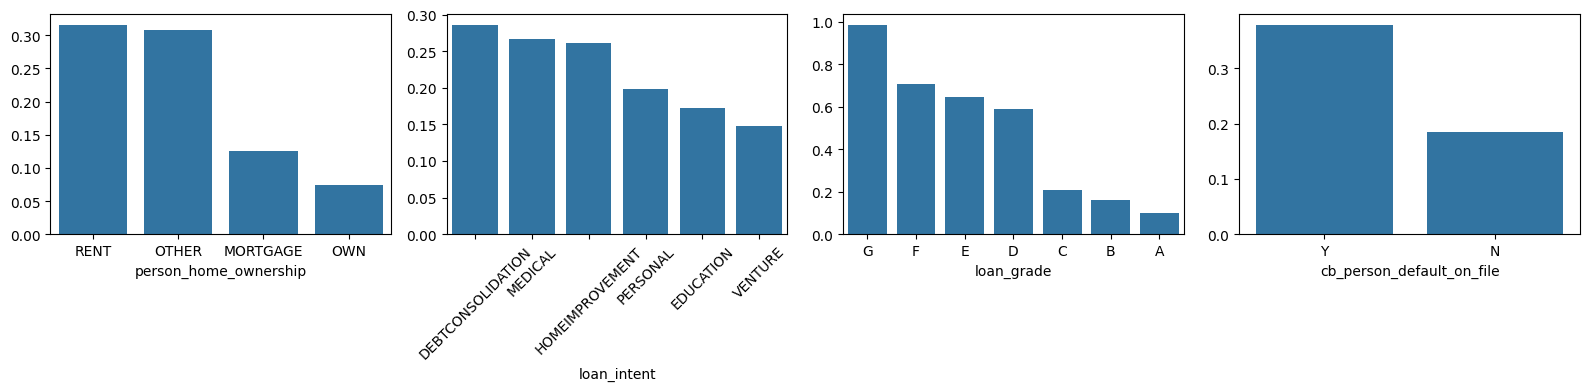

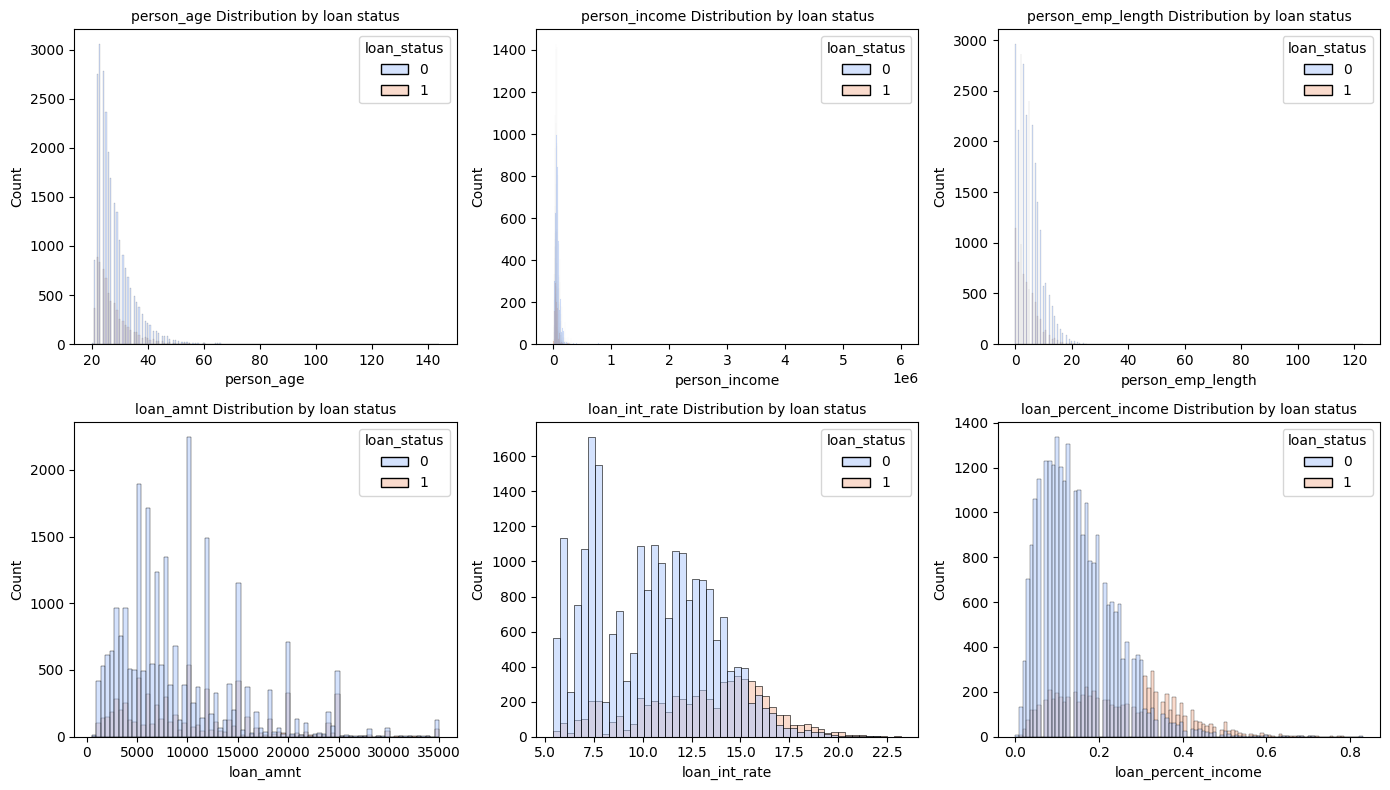

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,887
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [ ]:
cat_features = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[idx])

    if idx==1:
        axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(cat_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


numerical = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical):
    if idx < 6:
        sns.histplot(data=df, x=col, hue='loan_status', ax=axes[idx], palette='coolwarm')
        axes[idx].set_title(f'{col} Distribution by loan status', fontsize=10)

plt.tight_layout()
plt.show()

df.drop_duplicates(inplace=True)
df.isnull().sum()

# model

In [ ]:
X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)


# data preprocessing

num_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'
]

cat_cols = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
]

num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
    ]
)

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.head()


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Support Vector Classifier': SVC(class_weight='balanced', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Xgboost Classifier': XGBClassifier(n_estimator=400,  random_state=42),
    'Ligthgbm Classifier': lgb.LGBMClassifier(n_extimator=500,  random_state=42)
}


def train_classifier(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1_score = f1_score(y_test, y_pred)
    conf_matrix = classification_report(y_test, y_pred)

    return accuracy, precision, recall, F1_score, conf_matrix




In [ ]:
 model_result = {}

for name, model in models.items():
    print(f"-----------------------------------{name}-------------------------------------")
    accuracy, precision, recall, F1_score, conf_matrix = train_classifier(model, X_train_processed, y_train, X_test_processed, y_test)

    print(f"Accuracy Score: {accuracy:.4f}")
    print(f'Precision Score: {precision:.4f}')
    print(f'Recall Score: {recall:.4f}')
    print(f"F1-Score: {F1_score:.4f}")
    print('\nClassification Report:\n', conf_matrix)

    model_result[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }



# voting classifier


ensemble = VotingClassifier(
    estimators=list(zip(models.keys(), models.values())), voting='soft', verbose=0
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    ensemble, X_train_processed, y_train, X_test_processed, y_test
)

print("\n--------------------------Voting Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)

model_result['Voting Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }



# stacking classifier
base_models = [
    ('ET', ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ('XGB', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('CAT', CatBoostClassifier(iterations=1000, silent=True, random_state=42))
]

meta_model = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    stacking_clf, X_train_processed, y_train, X_test_processed, y_test
)


print("\n--------------------------Stacking Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)

model_result['Stacking Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }

-----------------------------------Logistic Regression-------------------------------------
Accuracy Score: 0.8152
Precision Score: 0.5557
Recall Score: 0.7736
F1-Score: 0.6468

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.87      5066
           1       0.56      0.77      0.65      1418

    accuracy                           0.82      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.82      0.83      6484

-----------------------------------Support Vector Classifier-------------------------------------
Accuracy Score: 0.8828
Precision Score: 0.7217
Recall Score: 0.7553
F1-Score: 0.7381

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92      5066
           1       0.72      0.76      0.74      1418

    accuracy                           0.88      6484
   macro avg       0.83      0.84      0.83  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:18:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy Score: 0.9380
Precision Score: 0.9618
Recall Score: 0.7461
F1-Score: 0.8403

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.96      0.75      0.84      1418

    accuracy                           0.94      6484
   macro avg       0.95      0.87      0.90      6484
weighted avg       0.94      0.94      0.94      6484

-----------------------------------Ligthgbm Classifier-------------------------------------
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Info] Number of positive: 5671, number of negative: 20261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data poin

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:23:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Warning] Unknown parameter: n_extimator
[LightGBM] [Info] Number of positive: 5671, number of negative: 20261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 25932, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218687 -> initscore=-1.273332
[LightGBM] [Info] Start training from score -1.273332
[LightGBM] [Warning] Unknown parameter: n_extimator

--------------------------Voting Classifier------------------------

Accuracy - 0.9345
Precision - 0.9568
Recall - 0.7334
F1-Score - 0.8303

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1

#Overwiev all Model performance

In [ ]:
results_df = pd.DataFrame(model_result).T.sort_values(by='Accuracy', ascending=False)
results_df.round(4)

,Accuracy,Precision,Recall,F1-score
Stacking Classifier,0.9391,0.9785,0.7377,0.8412
Xgboost Classifier,0.9380,0.9618,0.7461,0.8403
Ligthgbm Classifier,0.9374,0.9792,0.7292,0.8359
Voting Classifier,0.9345,0.9568,0.7334,0.8303
Gradient Boosting,0.9318,0.9630,0.7158,0.8212
Random Forest,0.9297,0.9791,0.6932,0.8117
Support Vector Classifier,0.8828,0.7217,0.7553,0.7381
Logistic Regression,0.8152,0.5557,0.7736,0.6468


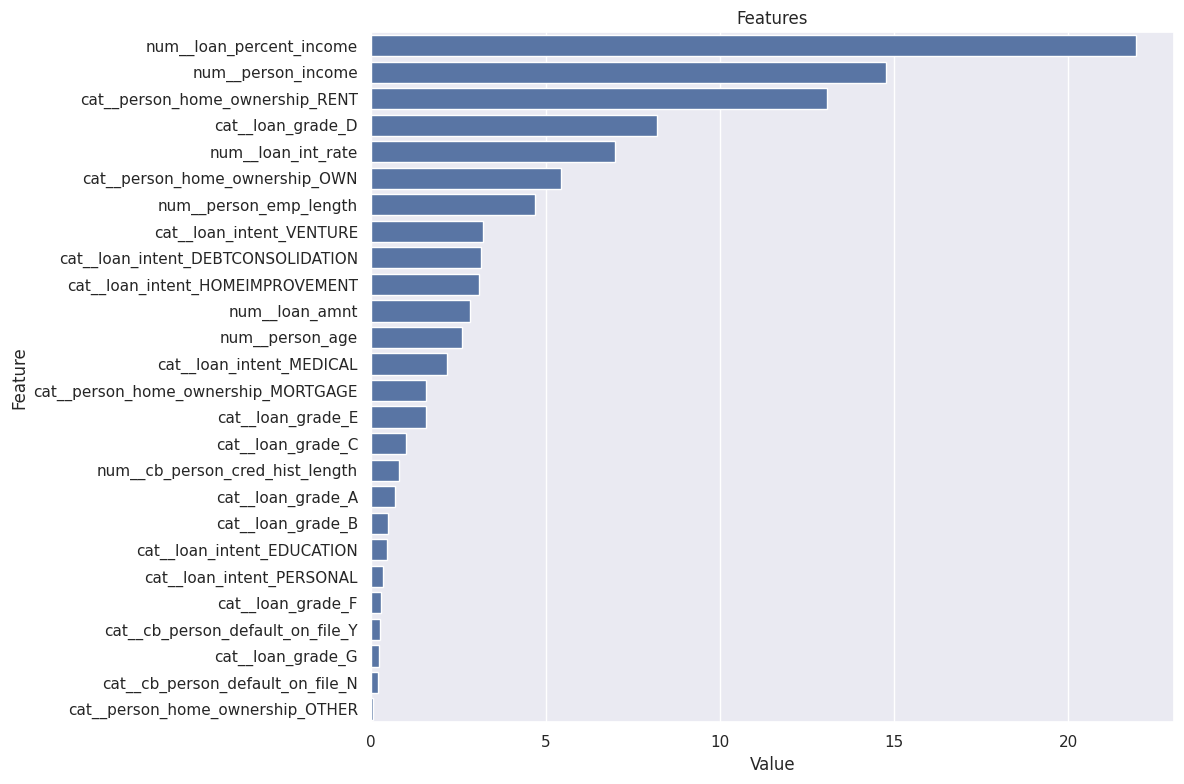

In [ ]:
def plot_importance(model, features, num=len(X_train_processed), save=False):

    feature_imp = pd.DataFrame({"Value": model.feature_importances_, "Feature": features.columns})
    plt.figure(figsize=(12, 8))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title("Features")
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig("importances.png")

model = CatBoostClassifier(silent=True)
model.fit(X_train_processed, y_train)

plot_importance(model, X_train_processed)

# whole code




In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df = pd.read_csv('/content/credit_risk_dataset.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df) * 100).round(2),
    "Unique Values": df.nunique(),
    "Unique Category": [df[col].unique() for col in df.columns],
})

info_df

corr_matrix = df.corr(numeric_only=True)
corr_matrix

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

loan_dist = df['loan_status'].value_counts()
loan_pct = df['loan_status'].value_counts(normalize=True) * 100

print("Loan Distribution:\n")
print(f"  Non-default:  {loan_dist[0]} ({loan_pct[0]:.2f}%)")  # 0
print(f"  Default:      {loan_dist[1]}  ({loan_pct[1]:.2f}%)") # 1

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(data=df, x='loan_status', hue='loan_status', legend=False, palette='viridis', ax=ax[0])
ax[0].set_title('Loan Distribution (Count)', fontsize=12)
ax[0].set_xlabel('Loan')
ax[0].set_ylabel('Count')

colors = ['#2ecc71', '#e74c3c']
ax[1].pie(loan_dist, labels=['Non-default', 'Default'], autopct='%1.1f%%',
          colors=colors, explode=(0, 0.1), shadow=True)
ax[1].set_title('Loan Distribution (Percentage)', fontsize=12)

plt.tight_layout()
plt.show()

cat_features = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    default_rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[idx])

    if idx==1:
        axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(cat_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()



X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)


# data preprocessing

num_cols = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'
]

cat_cols = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'
]

num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5))
])

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
    ]
)

#preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.head()


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Support Vector Classifier': SVC(class_weight='balanced', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Xgboost Classifier': XGBClassifier(n_estimator=400, verbose=0, random_state=42),
    'Ligthgbm Classifier': lgb.LGBMClassifier(n_extimator=500, verbose=0, random_state=42)
}


def train_classifier(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1_score = f1_score(y_test, y_pred)
    conf_matrix = classification_report(y_test, y_pred)

    return accuracy, precision, recall, F1_score, conf_matrix



    model_result = {}

for name, model in models.items():
    print(f"-----------------------------------{name}-------------------------------------")
    accuracy, precision, recall, F1_score, conf_matrix = train_classifier(model, X_train_processed, y_train, X_test_processed, y_test)

    print(f"Accuracy Score: {accuracy:.4f}")
    print(f'Precision Score: {precision:.4f}')
    print(f'Recall Score: {recall:.4f}')
    print(f"F1-Score: {F1_score:.4f}")
    print('\nClassification Report:\n', conf_matrix)

    model_result[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }



# voting classifier


ensemble = VotingClassifier(
    estimators=list(zip(models.keys(), models.values())), voting='soft', verbose=0
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    ensemble, X_train_processed, y_train, X_test_processed, y_test
)

print("\n--------------------------Voting Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)

model_result['Voting Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }



# stacking classifier
base_models = [
    ('ET', ExtraTreesClassifier(n_estimators=500, random_state=42)),
    ('XGB', XGBClassifier(eval_metric='logloss', random_state=42)),
    ('CAT', CatBoostClassifier(iterations=1000, silent=True, random_state=42))
]

meta_model = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

accuracy, precision, recall, F1_score, conf_matrix =  train_classifier(
    stacking_clf, X_train_processed, y_train, X_test_processed, y_test
)


print("\n--------------------------Stacking Classifier------------------------\n")
print(f"Accuracy - {accuracy:.4f}")
print(f"Precision - {precision:.4f}")
print(f"Recall - {recall:.4f}")
print(f'F1-Score - {F1_score:.4f}')
print("\nClassification Report:\n", conf_matrix)

model_result['Stacking Classifier'] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': F1_score,
    }


results_df = pd.DataFrame(model_result).T.sort_values(by='Accuracy', ascending=False)
results_df.round(4)


def plot_importance(model, features, num=len(X_train_processed), save=False):

    feature_imp = pd.DataFrame({"Value": model.feature_importances_, "Feature": features.columns})
    plt.figure(figsize=(12, 8))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title("Features")
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig("importances.png")

model = CatBoostClassifier(silent=True)
model.fit(X_train_processed, y_train)

plot_importance(model, X_train_processed)





# save model

In [ ]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(stacking_clf, "credit_model.pkl")

['credit_model.pkl']

In [ ]:
from google.colab import files

#files.download("credit_model.pkl")
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import xgboost
print(xgboost.__version__)

3.3.0


In [ ]:
import sklearn
import joblib
import pandas
import numpy

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
joblib: 1.5.3
pandas: 2.2.2
numpy: 2.0.2


In [ ]:
import sklearn
import joblib
import pandas
import numpy

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)

sklearn: 1.6.1
joblib: 1.5.3
pandas: 2.2.2
numpy: 2.0.2


In [ ]:
joblib.dump(stacking_clf, "credit_model.pkl")

['credit_model.pkl']

In [ ]:
import joblib

model = joblib.load("credit_model.pkl")
print(model)

StackingClassifier(cv=5,
                   estimators=[('ET',
                                ExtraTreesClassifier(n_estimators=500,
                                                     random_state=42)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=...
   

In [ ]:
import joblib

joblib.dump(stacking_clf, "credit_model.pkl", compress=3)
print("Model saved.")

Model saved.


In [ ]:
model = joblib.load("credit_model.pkl")
print("Model loaded successfully!")
print(model)

Model loaded successfully!
StackingClassifier(cv=5,
                   estimators=[('ET',
                                ExtraTreesClassifier(n_estimators=500,
                                                     random_state=42)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='logloss',
                                              feature_types=None,
                                          

In [ ]:
import joblib

joblib.dump(stacking_clf, "credit_model.pkl", compress=3)
joblib.dump(preprocessor, "preprocessor.pkl", compress=3)

['preprocessor.pkl']

In [ ]:
from google.colab import files

#files.download("credit_model.pkl")
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python -c "import xgboost; print('xgboost:', xgboost.__version__)"
!python -c "import sklearn; print('sklearn:', sklearn.__version__)"
!python -c "import joblib; print('joblib:', joblib.__version__)"
!python -c "import sys; print(sys.executable)"

xgboost: 3.3.0
sklearn: 1.6.1
joblib: 1.5.3
/usr/bin/python3


In [ ]:
import os

print(os.path.getsize("credit_model.pkl"))

108871736


In [ ]:
import os
import joblib

print("Size:", os.path.getsize("credit_model.pkl"))

model = joblib.load("credit_model.pkl")
print("Loaded successfully!")

Size: 108871736
Loaded successfully!


In [ ]:
import joblib
model = joblib.load("credit_model.pkl")
print(type(model))

<class 'sklearn.ensemble._stacking.StackingClassifier'>


In [ ]:
# Train CatBoost model
cat_model = CatBoostClassifier(
    iterations=1000,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train_processed, y_train)

CatBoostClassifier(iterations=1000, random_state=42, verbose=0)

In [ ]:
import joblib
from catboost import CatBoostClassifier

final_model = CatBoostClassifier(
    iterations=1000,
    silent=True,
    random_state=42
)

final_model.fit(X_train_processed, y_train)

joblib.dump(final_model, "credit_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

# Verify
joblib.load("credit_model.pkl")
print("SUCCESS")

SUCCESS


In [ ]:
import joblib
model = joblib.load("credit_model.pkl")
print(type(model))

<class 'catboost.core.CatBoostClassifier'>
